# AR segmentation: a simple baseline

This notebook mirrors `template/1_baseline_template.ipynb`. It trains the simplest possible
segmentation model and, more importantly, defines the metrics that the Surya fine-tune in the
next notebook will be scored with.

**Why a baseline?** A simple model that cannot overfit tells you what the big model actually
adds. Here the labels themselves were made by thresholding the magnetogram, so a linear pixel
classifier may already get surprisingly far. Whatever Surya scores only means something next to
this number.

This notebook assumes familiarity with **0_dataset_dataloader_ar.ipynb**.

### The baseline ladder

All rungs are the same script and metrics; only the config changes.

| baseline | config change | parameters | what it measures |
|---|---|---|---|
| learned \|B_los\| threshold | `channels: [hmi_m]`, `model.in_channels: 1` | 2 | how much of the task the labelling rule itself explains — the rule *is* a threshold on this channel |
| per-pixel logistic on 13 channels | default | 14 | how far a linear pixel classifier gets |
| Surya + adapters + linear 2D head | Notebook 2 | ~3 M trainable | what the foundation model adds |

The 14-parameter model cannot overfit: it has nowhere to put memories. Whatever Surya scores
only means something next to this number.

```mermaid
flowchart LR
    X["13 channels<br/>per pixel"] --> ABS["|x|<br/>(field strength, not sign)"] --> W["13 weights + 1 bias<br/>= a 1 × 1 convolution"] --> Z["raw score<br/>per pixel"] --> S["sigmoid → P(active region)"]
```

### Companion documents

| document | what it is for |
|---|---|
| `NOTEBOOKS_EXPLAINED.md` | all four notebooks and the labelling rule, in plain language |
| `GROUND_TRUTH_EXPLAINED.md` | where the answer key comes from, how it is made, how faithfully it reproduces |
| `ERRORS_NOTEBOOK_EXPLAINED.md` | the error-analysis notebook, section by section |


## Set your cuda visible device

**IMPORTANT:** Since we are sharing resources, please make sure that the cuda visible device you put here is the one assigned to your team and your machine.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

### Imports, and one setting that has to come first

`CUBLAS_WORKSPACE_CONFIG` is read exactly once, when the GPU maths library starts up. Setting
it after `torch` has been imported does nothing at all — no warning, no effect. That is why it
sits above the imports here and in every notebook in this app. **If you have already imported
`torch` in this kernel session, restart the kernel now.**

`sys.path.append("../../")` puts the repository root on the import path, which is what makes
`workshop_infrastructure` and `downstream_apps` importable from inside this folder.

In [2]:
# Must be set BEFORE torch is imported: cuBLAS reads this once, when it initializes, so
# setting it later has no effect. (Restart the kernel if torch was already imported.)
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import sys
import numpy as np
import matplotlib.pyplot as plt
import torch

# Gives the notebook access to workshop_infrastructure/ and downstream_apps/.
sys.path.append("../../")

from workshop_infrastructure.utils import build_scalers  # per-channel normalization stats

torch.set_float32_matmul_precision("medium")

### Lightning, and the preprocessing hook

`lightning` supplies the training loop, checkpointing and logging so none of it is
reimplemented per app. `functools.partial` is used to bind the channel order and scalers into
the preprocessing function the Lightning module calls before every batch.

In [3]:
import lightning as L
from functools import partial

## Load configuration

The config is the single source of truth. `load_ar_config()` parses `configs/config_script.yaml`
into a typed object, exactly as `finetune_ar_segmentation.py` does, so the same YAML behaves
identically here and in the script.

The `data:` section is parsed into `ARDataConfig` (see `configs.py`), which adds the AR-specific
keys on top of the shared `DataConfig`:

| key | meaning |
|---|---|
| `ar_mask_dir` | directory with the split CSVs and `data/YYYY/MM/*.h5` masks |
| `ar_mask_splits` | which mask CSVs to load (the Surya index decides train vs validation) |
| `ar_mask_key` | `union_with_intersect` (AR footprints) or `intersection` (the PILs) |
| `ar_pooling` | block-mean pooling of inputs and mask; 1 = native 4096x4096 |
| `ar_pos_weight` | up-weights AR pixels in the BCE loss (they are ~1.3 % of the disk) |
| `ar_threshold` | probability cut for IoU / Dice / precision / recall |

`AR_CONFIG` lets you point at a different YAML (for example one with local indices) without
editing the notebook.

| config property | consequence |
|---|---|
| unknown keys raise | a typo is an error naming the valid keys, never a silent no-op |
| paths relative to the config file | works from any working directory |
| `learning_rate: 0.001` | fine for 14 parameters; the same file notes ~1e-4 for Surya |


In [4]:
from downstream_apps.ar_segmentation.configs import load_ar_config

config_path = os.environ.get("AR_CONFIG", "./configs/config_script.yaml")
cfg = load_ar_config(config_path)
print(f"Loaded config for job: {cfg.job_id}")
print(f"  train index : {cfg.data.train_data_path}")
print(f"  masks       : {cfg.data.ar_mask_dir}  (key: {cfg.data.ar_mask_key})")
print(f"  s3 cache    : {cfg.data.s3_cache_dir}")

Loaded config for job: ar_segmentation_baseline
  train index : /home/jovyan/surya_workshop/data/indices/surya_aws_s3_train.csv
  masks       : /home/jovyan/scratch_space/AR_Seg_Uncertainty/data/assets/surya-bench-ar-segmentation  (key: union_with_intersect)
  s3 cache    : /home/jovyan/.cache/surya_workshop/helio_s3_cache


## Download assets

`ensure_assets()` fetches only what is missing from HuggingFace, so re-running this is free.
The AR masks are a separate dataset; fetch them once with `bash download_masks.sh` (about
1.3 GB, no login needed). The SDO inputs stream from the public `nasa-surya-bench` S3 bucket,
which needs a local cache directory: set `SURYA_WS_CACHE_DIR` or `data.s3_cache_dir`
(budget roughly 1 GB per unique timestep).

### The three "spaces" the data lives in

The pipeline is signum-log **then** z-score, so there are two different "inverse" operations:

| space | what the numbers are | how you get there |
|---|---|---|
| **normalised** | what the model sees: `sign(x)·log(1+|x|)`, then z-scored per channel | the dataset's `__getitem__` |
| **signum-log** | z-score undone, log compression kept | `scaler.inverse_transform()` — what the baseline consumes via `destandardize_channels` |
| **physical** | DN for the ultraviolet channels, **gauss** for the magnetic ones | `dataset.inverse_transform_data()` — for plotting, and for re-running the labelling rule |

Never assume one is the other; the reference block is at the top of
`workshop_infrastructure/datasets/helio.py`.


In [5]:
from workshop_infrastructure.assets import ensure_assets

ensure_assets(cfg, which=['scalers'])

scalers = build_scalers(info=cfg.data.scalers_path)
print(f"Loaded scalers for {len(scalers)} channels.")

Loaded scalers for 13 channels.


## Define the datasets and dataloaders

`build_helio_dataloaders()` constructs the train and validation datasets and wraps them in
DataLoaders. It fills in every generic argument from the config; only the AR-specific arguments
are passed here, and they are the same list `finetune_ar_segmentation.py` passes.

The validation set gets `phase="val"` and is not shuffled.

### How images and outlines are paired

| rule | consequence |
|---|---|
| Outlines are **hourly**; images are every **12 minutes** | only on-the-hour images pair — about 1 in 5 |
| Pairing is an **exact timestamp match** | no interpolation, no nearest-neighbour |
| Only catalogue rows with `present == 1` are used | hours with no valid magnetogram are dropped |
| Both maps are loaded as `> 0` | the two keys are stored differently (0/255 and 0/1); this makes both a float 0/1 image |
| Train vs validation is decided by the **image** index | the four outline CSVs are loaded only as a lookup table; the image index's validation set is mid-to-late January each year, and the two do not overlap in time |
| No vertical flips | the base loader would flip the image but not the outline |

### How much of the Sun is active region — it depends on the year

Measured from the released outlines:

| year | AR coverage | background : AR |
|---|---|---|
| 2010 | 0.19 % | 516 : 1 |
| 2011 | 1.00 % | 100 : 1 |
| 2013 | 1.37 % | 73 : 1 |
| **2014** | **1.80 %** | **55 : 1** |
| 2016 | 0.47 % | 215 : 1 |
| 2019 | 0.023 % | 4285 : 1 |

A 78-fold swing over the 11-year solar cycle. "About 1 % of the disk" is a solar-maximum
figure. Two things follow: the imbalance a model faces depends on *which years* it sees, and
`max_samples` takes the **earliest** timestamps — mid-January 2011, about one pixel in a
thousand. `3_errors_ar.ipynb` shows what that does to training and how to choose better.


In [6]:
from downstream_apps.ar_segmentation.datasets.ar_dataset import ARSegmentationDataset
from workshop_infrastructure.datasets.builders import build_helio_dataloaders

train_data_loader, val_data_loader = build_helio_dataloaders(
    cfg,
    ARSegmentationDataset,
    scalers=scalers,
    num_workers=2,          # fewer workers than the script: notebooks start faster
    #### Downstream (DS) specific parameters
    return_surya_stack=True,
    max_number_of_samples=cfg.data.max_samples,
    ds_mask_dir=cfg.data.ar_mask_dir,
    ds_mask_splits=cfg.data.ar_mask_splits,
    ds_mask_key=cfg.data.ar_mask_key,
    pooling=cfg.data.ar_pooling,
)

batch_size = cfg.batch_size
print(f"train: {len(train_data_loader.dataset)} samples | "
      f"val: {len(val_data_loader.dataset)} samples | batch_size: {batch_size}")

train: 10 samples | val: 10 samples | batch_size: 1


### Inspect one batch

Pull one batch and print the shape of everything in it. Shapes are the dominant source of
bugs in this kind of work, so this is worth a cell of its own:

| key | shape | meaning |
|---|---|---|
| `ts` | `[B, C, T, H, W]` = `[1, 13, 1, 4096, 4096]` | batch, channels, input timesteps, height, width |
| `forecast` | `[B, H, W]` | the outline; the Lightning module adds a channel axis → `[B, 1, H, W]` |
| `time_delta_input` | `[B, T]` | minutes of each input frame relative to "now" |
| `ds_index` | list of `B` strings | ISO timestamps |

One sample of `ts` in float32 is 13 × 4096 × 4096 × 4 bytes ≈ **0.87 GB**, which is why
`batch_size: 1` and why the loaders, not the GPU, are usually the bottleneck.

In [7]:
batch = next(iter(train_data_loader))
print({k: (tuple(v.shape) if hasattr(v, "shape") else type(v).__name__) for k, v in batch.items()})

{'ts': (1, 13, 1, 4096, 4096), 'time_delta_input': (1, 1), 'forecast': (1, 4096, 4096), 'ds_index': 'list'}


## Define the simple baseline model

For a per-pixel task, "linear regression" means **per-pixel logistic regression**: one weight
per input channel plus a bias, applied at every pixel independently. In PyTorch that is a 1x1
convolution. With the 13 Surya channels the whole model has **14 parameters**.

`PixelLogisticModel` (in `models/pixel_logistic.py`) takes `|x|` of its inputs first. AIA
channels are non-negative already; for the signed HMI channels this turns the input into field
strength, which is what defines an active region regardless of polarity.

Like the template's linear baseline it works in **signum-log space**, so `destandardize_channels`
undoes the per-channel z-score before every forward pass (the log compression stays: raw values
span too many orders of magnitude for one linear layer).

Two configurations are worth running:

- all 13 channels (the default);
- `channels: [hmi_m]` with `model.in_channels: 1` in the YAML, a learned |B_los| threshold,
  which is close to the recipe the labels were generated with.

### Why the absolute value, and why signum-log space

| choice | reason |
|---|---|
| `|x|` before the linear layer | an active region is defined by field *strength*; the sign (polarity) is noise for this purpose. AIA channels are non-negative anyway |
| signum-log space, not physical | raw values span too many orders of magnitude for one linear layer; the log compression stays, only the z-score is undone (`destandardize_channels`) |
| a 1 × 1 convolution | the same 14 numbers applied independently at every pixel — literally logistic regression per pixel |

Because the answer key was made by thresholding `hmi_m`, the two-parameter configuration is
close to the labelling rule itself. Run it: it is the honest zero of the ladder.


In [8]:
from downstream_apps.ar_segmentation.models.pixel_logistic import PixelLogisticModel, destandardize_channels

n_input_timestamps = cfg.model.time_embedding.time_dim
n_channels = len(cfg.data.channels)

model = PixelLogisticModel(in_channels=n_channels, time_dim=n_input_timestamps)
print(model)
print("parameters:", sum(p.numel() for p in model.parameters()))

PixelLogisticModel(
  (linear): Conv2d(13, 1, kernel_size=(1, 1), stride=(1, 1))
)
parameters: 14


Test that the model manipulates a batch as expected. The output is untrained and meaningless;
this only checks the shapes, which are the dominant source of error in this kind of work.

| tensor | shape |
|---|---|
| input `ts` | `[1, 13, 1, 4096, 4096]` |
| output logits | `[1, 1, 4096, 4096]` — one raw score per pixel |


In [9]:
preprocess_fn = partial(destandardize_channels, channel_order=cfg.data.channels, scalers=scalers)

output = model(preprocess_fn(batch))
print("input ts:", tuple(batch["ts"].shape), "->", "logits:", tuple(output.shape))

input ts: (1, 13, 1, 4096, 4096) -> logits: (1, 1, 4096, 4096)


## Define your metrics

`ARMetrics` (in `metrics/ar_metrics.py`) follows the template's four-mode contract:

| mode | what | backpropagates |
|---|---|---|
| `train_loss` | binary cross-entropy with logits, optional `pos_weight` | yes |
| `val_loss` | same BCE; **this is what `ModelCheckpoint` monitors** | no |
| `train_metrics` | empty on purpose (IoU over 16.8 M pixels per step is not worth it) | no |
| `val_metrics` | IoU, Dice, precision, recall at `ar_threshold`, and the AR pixel fraction | no |

Metrics are pooled over all pixels in the batch. A batch with an empty mask and an empty
prediction scores IoU 1: predicting nothing on a quiet Sun is correct.

**This is the class both the baseline and Surya are scored with.** That is what makes the
comparison between the two meaningful.

### The arithmetic behind the scorecard

At a probability cut *t*, per image:

| quantity | definition |
|---|---|
| true positives TP | predicted AR and truly AR |
| false positives FP | predicted AR, truly background |
| false negatives FN | predicted background, truly AR |
| **IoU** (Jaccard) | TP / (TP + FP + FN) |
| **Dice** (F1) | 2 TP / (2 TP + FP + FN) |
| precision | TP / (TP + FP) — of what it flagged, how much was real |
| recall | TP / (TP + FN) — of what was real, how much it found |

An image with an empty outline and an empty prediction scores 1: predicting nothing on a quiet
Sun is correct. Scores are **pooled over all pixels in the batch**, not averaged per image, so a
large region dominates and a quiet image barely counts; with `batch_size: 1` that is per-image.

Why overlap and never accuracy: with active regions at ~1 % of the disk, "background
everywhere" is ~99 % pixel-accurate and completely useless.

`ar_pos_weight` up-weights the rare positive pixels in the training penalty; the default
(`null`) matches the released Surya example — and is one of the reasons the first run of
Notebook 3 collapsed. Measure the imbalance before choosing it.


In [10]:
from downstream_apps.ar_segmentation.metrics.ar_metrics import ARMetrics

metric_kwargs = dict(threshold=cfg.data.ar_threshold, pos_weight=cfg.data.ar_pos_weight)
train_loss_metrics = ARMetrics("train_loss", **metric_kwargs)
val_loss_metrics = ARMetrics("val_loss", **metric_kwargs)
train_evaluation_metrics = ARMetrics("train_metrics", **metric_kwargs)
validation_evaluation_metrics = ARMetrics("val_metrics", **metric_kwargs)

Evaluate them on the untrained model's output. The target gets a channel axis, exactly as the
Lightning module does, so it matches the [B, 1, H, W] output. The loss should sit near
`log(2) = 0.69`, and IoU near the AR fraction: a random model is about as good as guessing.

| quantity | expected for an untrained model | why |
|---|---|---|
| training loss (BCE) | ≈ 0.69 = ln 2 | coin-flipping |
| IoU | ≈ the AR pixel fraction | a random model is about as good as guessing |


In [11]:
target = batch["forecast"].unsqueeze(1).float()
print("train loss:", {k: round(v.item(), 4) for k, v in train_loss_metrics(output, target)[0].items()})
print("val metrics:", {k: round(v.item(), 4) for k, v in validation_evaluation_metrics(output, target)[0].items()})

train loss: {'bce': 0.6348}


val metrics: {'iou': 0.0, 'dice': 0.0001, 'precision': 0.0, 'recall': 0.0013, 'pos_frac': 0.0003}


## The PyTorch Lightning module

The template's Lightning module is task-agnostic: it calls the model on the batch, computes the
metrics on `(output, batch["forecast"].unsqueeze(1))` and logs them. It is reused here under the
name `SegmentationLightningModule` (see `lightning_modules/pl_segmentation.py`).

**_It is the same module for the baseline and for Surya._**

| the module does | detail |
|---|---|
| calls the model on the batch | after `preprocess_fn`, if one is given |
| computes `train_loss` and backpropagates it | logged as `train_loss` and `train_loss_<name>` |
| computes `val_loss` on the validation set | **this is what `ModelCheckpoint` monitors** |
| logs `val_metrics` | reported only; they never select a checkpoint |
| configures Adam | learning rate from the config |


In [12]:
from downstream_apps.ar_segmentation.lightning_modules.pl_segmentation import SegmentationLightningModule

## Set your global seeds

Training uses stochastic gradient descent; fixing the seeds makes the exercise reproducible.

### What "reproducible" means here

| setting | effect |
|---|---|
| `training.seed` | seeds Python, NumPy and torch; the loaders' shuffle order and worker RNGs come from it explicitly |
| `training.deterministic: false` (default) | fastest; results are **not** bit-reproducible out of the box |
| `warn` | the setting to use when comparing runs |
| `true` | ~20 % slower; incompatible with `model.learned_flow: true` |
| `CUBLAS_WORKSPACE_CONFIG` before importing torch | required for deterministic cuBLAS; inert if set later |


In [13]:
L.seed_everything(cfg.seed, workers=True)

Seed set to 42


42

## Initialize the Lightning module

The `preprocess_fn` hook applies the inverse standardization before every model call, so the
transformation lives with the training mechanics and not inside the model.

`preprocess_fn` runs `destandardize_channels` on every batch before the model sees it, moving
`ts` from normalised to signum-log space. Keeping that transformation in the training
mechanics rather than inside the model is what lets Notebook 2 reuse the same module with no
preprocessing at all.


In [14]:
metrics = {
    "train_loss": train_loss_metrics,
    "val_loss": val_loss_metrics,
    "train_metrics": train_evaluation_metrics,
    "val_metrics": validation_evaluation_metrics,
}

lit_model = SegmentationLightningModule(
    model, metrics, lr=cfg.learning_rate, batch_size=batch_size, preprocess_fn=preprocess_fn
)

## Logging

Set `use_wandb = True` to log to Weights and Biases in addition to the CSV logger. The first
run on a machine asks you to log in. The CSV logger writes `runs/<project>/version_N/metrics.csv`,
which is enough for the comparisons in this exercise.

| logger | writes | note |
|---|---|---|
| `CSVLogger("runs", ...)` | `runs/<project>/version_N/metrics.csv` | one row per logged step; validation rows have the `val_*` columns filled |
| `WandbLogger` (optional) | Weights & Biases | first run on a machine asks you to log in |

`runs/` is ignored by git: it holds logs, checkpoints and executed notebooks.


In [15]:
from lightning.pytorch.loggers import CSVLogger, WandbLogger

use_wandb = False
project_name = cfg.wandb_project
run_name = "ar_baseline_experiment_1"

loggers = [CSVLogger("runs", name=project_name)]
if use_wandb:
    loggers.append(WandbLogger(entity=cfg.wandb_entity, project=project_name, name=run_name,
                               log_model=False, save_dir="./wandb/wandb_tmp"))

## Initialize the trainer

`accelerator="auto"` uses the GPU when there is one. The baseline is tiny, so it runs fine on
CPU too; the time goes into reading the data, not the model.

| trainer setting | effect |
|---|---|
| `accelerator="auto"` | GPU if there is one; the baseline is fine on CPU — the time goes into reading data |
| `ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=1)` | keeps the epoch with the lowest validation loss |
| `log_every_n_steps=2` | one CSV row per two training steps |


In [16]:
from lightning.pytorch.callbacks import ModelCheckpoint

max_epochs = 2

trainer = L.Trainer(
    max_epochs=max_epochs,
    accelerator="auto",
    devices="auto",

    logger=loggers,
    callbacks=[ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=1)],
    log_every_n_steps=2,
)

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


## Fit the model

### How to read the training metrics

Watch **precision and recall together**, not the loss:

| signature | precision | recall | meaning |
|---|---|---|---|
| **Collapse** | → 1.0 | → 0 | predicts nothing; *the loss keeps improving while this happens* |
| **Over-correction** | → 0 | → 1.0 | flags everything; `ar_pos_weight` too high |
| **Healthy** | both away from 0 and 1 | | real predictions, wrong in both directions, improving |

This is not hypothetical: the first run of `3_errors_ar.ipynb` collapsed exactly this way
(recall 0.0054 → 0.000035 while the loss fell from 0.021 to 0.013). Three causes — the
quietest images in the archive, no `ar_pos_weight`, and too high a learning rate for Surya —
are all addressed there.


In [17]:
trainer.fit(lit_model, train_data_loader, val_data_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



  | Name  | Type               | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | model | PixelLogisticModel | 14     | train | 0    
-------------------------------------------------------------
14        Trainable params
0         Non-trainable params
14        Total params
0.000     Total estimated model params size (MB)
2         Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=2` reached.


## Read the results

The CSV logger records every validation metric per epoch. `val_metric_iou` and `val_metric_dice`
are the numbers to carry over to the Surya notebook.

| column | meaning |
|---|---|
| `val_loss` | the validation objective — what selected the checkpoint |
| `val_metric_iou`, `val_metric_dice` | overlap scores; **carry these to Notebook 2** |
| `val_metric_precision`, `val_metric_recall` | the diagnostic pair (see above) |
| `val_metric_pos_frac` | the true AR pixel fraction of the validation set |

A score without an interval is not yet a result; Notebook 3 puts the interval on it.


In [18]:
import pandas as pd

metrics_csv = os.path.join(loggers[0].log_dir, "metrics.csv")
df = pd.read_csv(metrics_csv)
val_cols = [c for c in df.columns if c.startswith("val_")]
print(df[["epoch"] + val_cols].dropna(subset=val_cols, how="all").to_string(index=False))

 epoch  val_loss  val_loss_bce  val_metric_dice  val_metric_iou  val_metric_pos_frac  val_metric_precision  val_metric_recall
     0  0.629900      0.629900              0.0             0.0             0.001037                   0.0                0.0
     1  0.609203      0.609203              0.0             0.0             0.001037                   0.0                0.0


## Look at a prediction

Numbers first, pictures second: plot the predicted probability map next to the mask for one
validation sample. The third panel is the thresholded prediction, which is what IoU scores.

### What the three panels are

| panel | shows | note |
|---|---|---|
| left | **P(active region)** — the model's confidence at every pixel, 0 to 1 | continuous; this is the model's actual output |
| middle | the same map cut at `ar_threshold` (0.5) | **this is what IoU scores**; every hesitant value is flattened to yes/no first |
| right | the true outline | the answer key |

The left panel is the one to stare at. The model does not output an outline; it outputs a
confidence surface, and the cut discards the gradation — exactly where the model is telling
you it is unsure. Recovering that information is what `3_errors_ar.ipynb` is for.


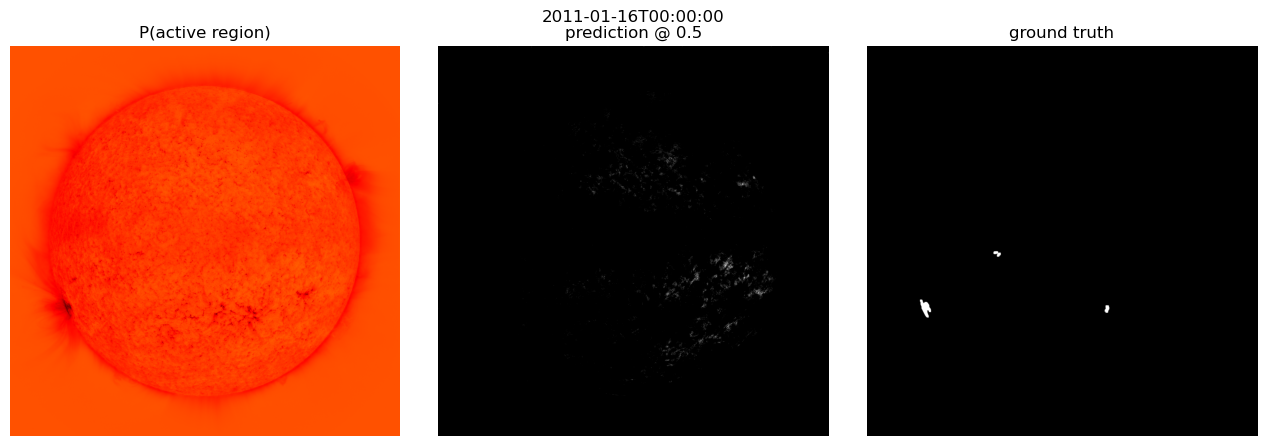

In [19]:
lit_model.eval()
val_batch = next(iter(val_data_loader))
with torch.no_grad():
    b = lit_model.preprocess_fn(val_batch) if getattr(lit_model, "preprocess_fn", None) else val_batch
    prob = torch.sigmoid(lit_model(b).float())[0, 0].cpu().numpy()
mask = val_batch["forecast"][0].numpy()

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(prob, cmap="hot", vmin=0, vmax=1); axes[0].set_title("P(active region)")
axes[1].imshow(prob >= cfg.data.ar_threshold, cmap="gray"); axes[1].set_title(f"prediction @ {cfg.data.ar_threshold}")
axes[2].imshow(mask, cmap="gray"); axes[2].set_title("ground truth")
for ax in axes:
    ax.axis("off")
plt.suptitle(val_batch["ds_index"][0])
plt.tight_layout()

## Conclusion

You now have a baseline score and, more importantly, a fixed way of scoring. Continue with
**2_finetune_ar.ipynb**, which swaps the 14-parameter model for Surya with LoRA adapters and
leaves everything else untouched.

Notebook 2 changes exactly one thing — the model — and leaves the data, the scorecard, the
Lightning module and the seeds untouched. That is what makes the comparison legitimate, and
Notebook 3 is what makes it honest.
